TỔNG QUAN CHƯƠNG 2
Dataset: AirPassengers (Monthly, 1949–1960)
Biến: Passengers
Tần suất: Monthly
Mục tiêu chương 2: Hiểu cấu trúc dữ liệu – chưa dự báo

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import STL

plt.rcParams["figure.figsize"] = (10, 5)

# Bài tập 1: Tính và phân tích ACF/PACF
1. Tải và xem trước dữ liệu (head, info, plot).
2. Tính ACF, PACF đến 40 lags.
3. Kết luận:
• Chuỗi có tự tương quan mạnh không?
• Có xu hướng/mùa vụ thể hiện qua ACF/PACF không?
• Lag nào quan trọng nhất?

## Bài tập 1 – 
# câu 1: Tải và xem trước dữ liệu (head, info, plot)

            Passengers
Month                 
1949-01-01         112
1949-02-01         118
1949-03-01         132
1949-04-01         129
1949-05-01         121
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 144 entries, 1949-01-01 to 1960-12-01
Data columns (total 1 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Passengers  144 non-null    int64
dtypes: int64(1)
memory usage: 2.2 KB
None


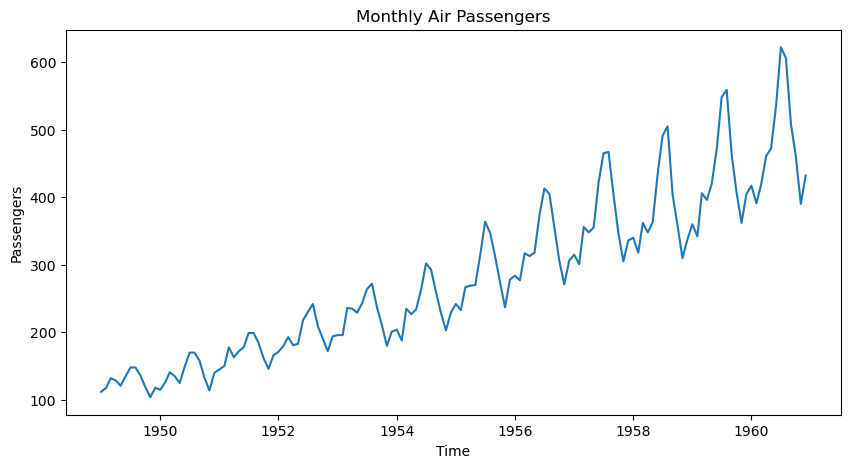

In [10]:
# Load data
df = pd.read_csv("data/airline-passengers.csv")

# Rename columns cho đẹp (nếu cần)
df.columns = ["Month", "Passengers"]

# Convert to datetime
df["Month"] = pd.to_datetime(df["Month"])

# Set index
df.set_index("Month", inplace=True)

# Xem dữ liệu
print(df.head())
print(df.info())

# Plot
plt.figure()
plt.plot(df.index, df["Passengers"])
plt.title("Monthly Air Passengers")
plt.xlabel("Time")
plt.ylabel("Passengers")
plt.show()


Data length: 144 quan sát (tương ứng với 12 năm × 12 tháng).

Data range: Từ 1949-01-01 đến 1960-12-01. Giá trị hành khách dao động từ 112 (tháng 1/1949) đến 606 (tháng 7/1960).


- Trend: Có xu hướng tăng dài hạn, số hành khách tăng đều qua các năm.

- Seasonality:

Chu kỳ lặp: 12 tháng

Mỗi năm đều có: Đỉnh khoảng tháng 6–8, Đáy khoảng tháng 1–2, 11

Dao động theo mùa vụ hàng năm (cao điểm mùa hè, thấp điểm mùa đông).

Biên độ dao động ngày càng lớn theo thời gian

*giai thich: Biên độ dao động ngày càng lớn theo thời gian trong chuỗi thời gian có nghĩa là độ biến động (phương sai) của dữ liệu tăng lên theo thời gian, cho thấy dữ liệu trở nên kém ổn định và khó dự đoán hơn ở các mốc thời gian xa hơn trong tương lai, thường biểu hiện qua việc xuất hiện thành phần xu hướng hoặc tính phi dừng (non-stationarity). Điều này cần được xử lý trong dự báo bằng các mô hình như biến đổi dữ liệu (ví dụ: vi phân) hoặc sử dụng các kỹ thuật mô hình hóa phù hợp hơn để bắt được sự thay đổi này, nếu không dự báo sẽ kém chính xá

## Câu 2. Tính ACF, PACF đến 40 lags.


<Figure size 1000x500 with 0 Axes>

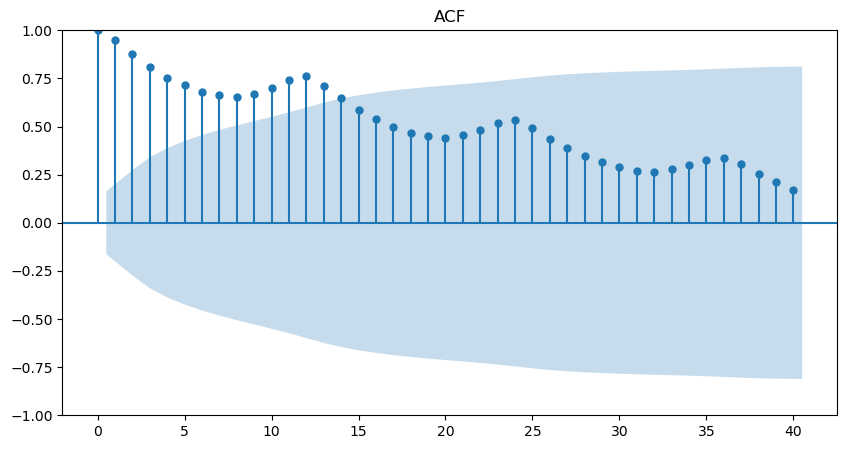

<Figure size 1000x500 with 0 Axes>

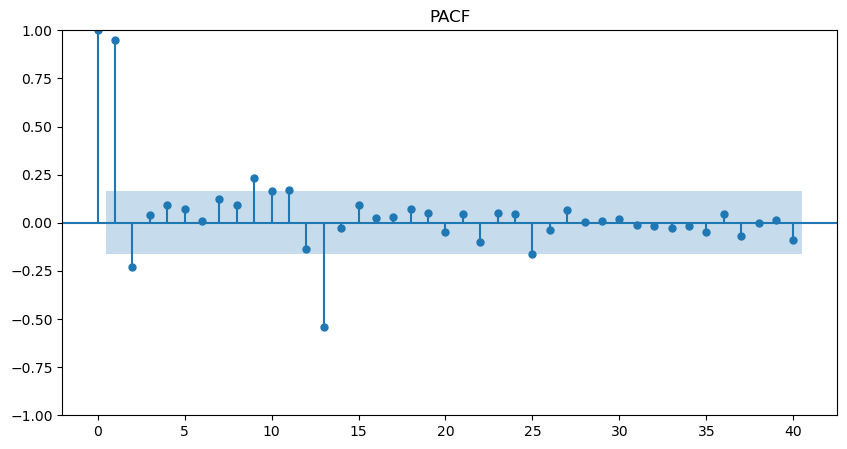

In [11]:
# from statsmodels.graphics.tsaplots import plot_acf, plot_pacf 

plt.figure()
plot_acf(df["Passengers"], lags=40)
plt.title("ACF")
plt.show()

plt.figure()
plot_pacf(df["Passengers"], lags=40, method="ywm")
plt.title("PACF")
plt.show()


# Phân tích ACF (Autocorrelation Function)
Nhận xét từ đồ thị ACF

- ACF tại lag 1 rất cao (~0.98).
- Các hệ số ACF:
    - Giảm rất chậm theo số lag (không cắt nhanh).
    - Vẫn lớn và có ý nghĩa thống kê đến lag 40.

- Xuất hiện các gợn sóng định kỳ (peaks nhẹ) quanh:
    - lag ≈ 12, 24, 36

=> ACF giảm chậm → chuỗi không dừng, có xu hướng (trend).
- Các đỉnh lặp lại theo chu kỳ → tồn tại mùa vụ 12 tháng.
- Không phải nhiễu trắng.
# Phân tích PACF (Partial Autocorrelation Function)
Nhận xét từ đồ thị PACF

- Lag 1 rất lớn (~0.9) → vượt rõ ràng khoảng tin cậy.
- Các lag sau:
    - Phần lớn nằm trong khoảng tin cậy
    - Có một vài spike nhỏ:
        - lag ≈ 12 (âm mạnh)
        - một vài lag rải rác nhưng không liên tục

=> PACF cắt mạnh sau lag 1
- Spike tại lag 12 → ảnh hưởng mùa vụ theo năm.
- Không có cấu trúc AR bậc cao rõ ràng.

## Câu 3. KẾT LUẬN:

Chuỗi có tự tương quan mạnh không? 
- Có. AirPassengers thể hiện tự tương quan rất mạnh, nhiều giá trị ACF vượt dải tin cậy và giảm chậm theo lag
- Điều này cho thấy: Giá trị hiện tại phụ thuộc mạnh vào các giá trị trong quá khứ. Chuỗi có “trí nhớ dài hạn”, không phải là chuỗi ngẫu nhiên.
=> Do đó, có thể kết luận rằng AirPassengers không phải white noise và có cấu trúc rõ ràng để phân tích và dự báo.

Chuỗi có xu hướng (trend) và mùa vụ (seasonality) thể hiện qua ACF/PACF không?
- Có

- Xu hướng (Trend)
Trên biểu đồ ACF, các giá trị autocorrelation: Bắt đầu rất cao ở lag nhỏ (gần 1). Giảm dần rất chậm khi lag tăng. Đặc điểm này là dấu hiệu điển hình của chuỗi có xu hướng (trend).
=> Điều đó phù hợp với thực tế: Số lượng hành khách hàng không tăng dần theo thời gian từ năm 1949 đến 1960. Trung bình của chuỗi không ổn định theo thời gian -> chuỗi không dừng (Không cắt → chuỗi không dừng).

- Mùa vụ (Seasonality)
Trên biểu đồ ACF, xuất hiện các đỉnh lặp lại rất rõ tại:
lag = 12, lag = 24, lag = 36
PACF có spike tại lag 12

- Vì dữ liệu là theo tháng, nên: lag = 12 tương ứng với chu kỳ 1 năm. Điều này cho thấy mỗi năm số hành khách có xu hướng lặp lại theo cùng một quy luật

Lag nào quan trọng nhất?
- Lag = 1
Trên biểu đồ PACF, cột tại lag = 1: Cao vượt trội, vượt rõ ràng dải tin cậy 95%
Điều này cho thấy: Giá trị của tháng hiện tại phụ thuộc trực tiếp và mạnh nhất vào tháng liền trước. Ảnh hưởng này là trực tiếp, không phải do các lag trung gian.
=> Vì vậy, lag = 1 là độ trễ quan trọng nhất đối với chuỗi.
- Lag = 12
Trên biểu đồ ACF, lag = 12 có đỉnh rất rõ.
Điều này cho thấy: Tháng hiện tại có mối liên hệ mạnh với cùng tháng của năm trước.
=> Do đó: lag = 12 là lag mùa vụ quan trọng

# Bài tập 2: Kiểm tra White Noise
1. Sinh dữ liệu white noise bằng NumPy (1000 điểm).
2. Vẽ ACF → kiểm tra xem các lag có nằm trong ngưỡng tin cậy 95% 
không.
3. So sánh ACF của white noise với ACF của chuỗi AirPassengers.
4. Viết 5 dòng mô tả sự khác nhau.

## Câu 1. Sinh dữ liệu white noise bằng NumPy (1000 điểm).

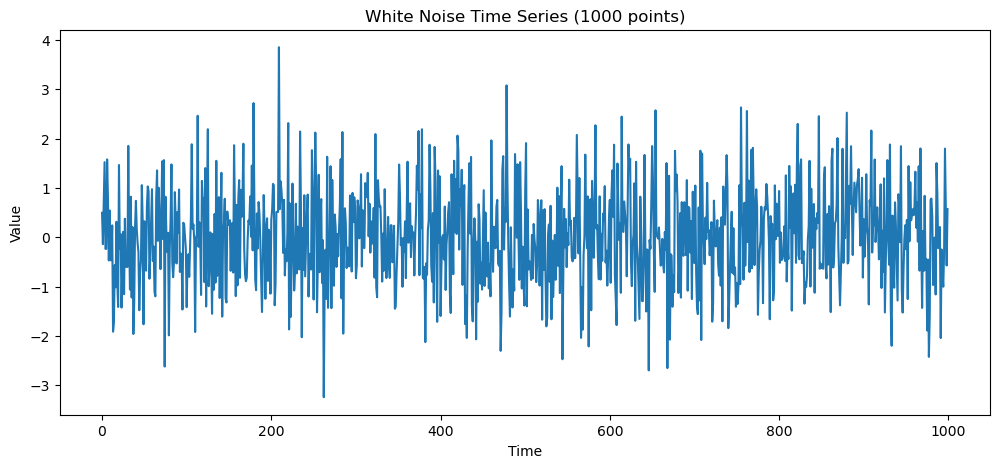

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf

np.random.seed(42)

white_noise = np.random.normal(
    loc=0,
    scale=1,
    size=1000
)

plt.figure(figsize=(12, 5))
plt.plot(white_noise)
plt.title("White Noise Time Series (1000 points)")
plt.xlabel("Time")
plt.ylabel("Value")
plt.show()


## Câu 2. Vẽ ACF → kiểm tra xem các lag có nằm trong ngưỡng tin cậy 95% 

<Figure size 1000x500 with 0 Axes>

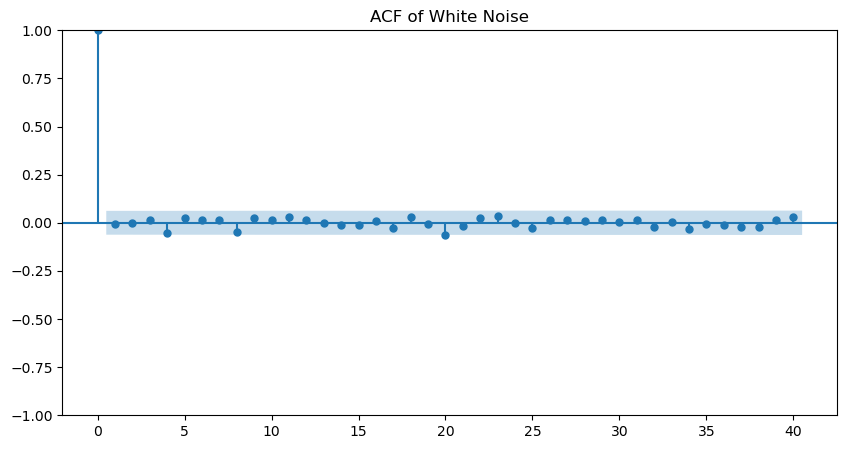

In [20]:
plt.figure(figsize=(10, 5))
plot_acf(white_noise, lags=40)
plt.title("ACF of White Noise")
plt.show()


Quan sát ACF White Noise
- Tất cả các hệ số ACF (trừ lag 0):
- Dao động quanh 0
- Nằm trong ngưỡng tin cậy 95% (±1.96/√N)
- Không có lag nào nổi bật hoặc có cấu trúc rõ ràng.
- Các spike xuất hiện là ngẫu nhiên, không có quy luật.
=>Kết luận 
- Chuỗi thỏa mãn white noise
- Không tồn tại tự tương quan có ý nghĩa thống kê.Nhận xét

## Câu 3. So sánh ACF của white noise với ACF của chuỗi AirPassengers.

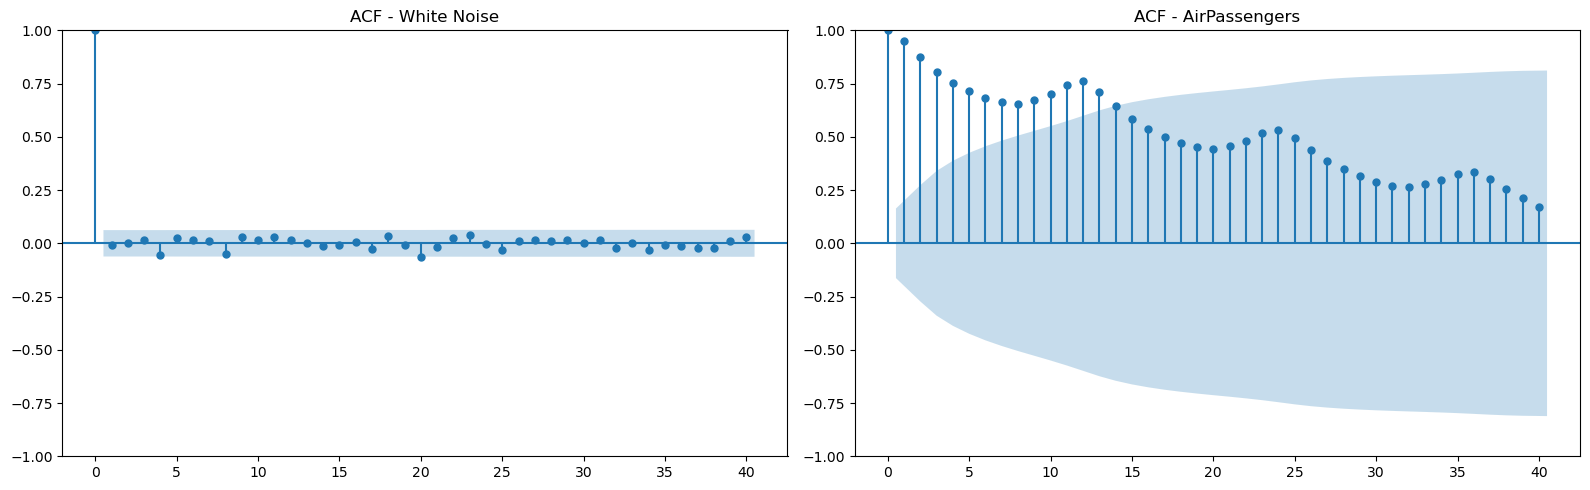

In [19]:
import pandas as pd

df = pd.read_csv("data/airline-passengers.csv")
air = df["Passengers"]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

plot_acf(white_noise, lags=40, ax=axes[0])
axes[0].set_title("ACF - White Noise")

plot_acf(air, lags=40, ax=axes[1])
axes[1].set_title("ACF - AirPassengers")

plt.tight_layout()
plt.show()


## Câu 4. Viết 5 dòng mô tả sự khác nhau.
Chuỗi white noise dao động ngẫu nhiên quanh 0, không có xu hướng và không tồn tại tự tương quan, thể hiện qua ACF hầu hết nằm trong ngưỡng tin cậy 95%. Ngược lại, chuỗi AirPassengers có ACF rất cao tại các lag nhỏ và giảm chậm theo thời gian. Nhiều lag của AirPassengers vượt quá ngưỡng tin cậy, phản ánh sự phụ thuộc mạnh vào quá khứ. Ngoài ra, AirPassengers thể hiện rõ mùa vụ với các đỉnh tại lag 12 và các bội số của nó. Do đó, AirPassengers không phải white noise, trong khi chuỗi sinh ngẫu nhiên là white noise điển hình.

# Bài tập 3: Phân rã chuỗi thời gian (Decomposition)
1. Chọn chuỗi dữ liệu theo tháng hoặc theo quý.
2. Dùng phương pháp STL hoặc classical decomposition.
3. Vẽ 4 thành phần: Observed, Trend, Seasonal, Residual
4. Mô tả:
- Xu hướng tăng/giảm?
- Mùa vụ mạnh hay yếu?
- Residual có giống white noise không?

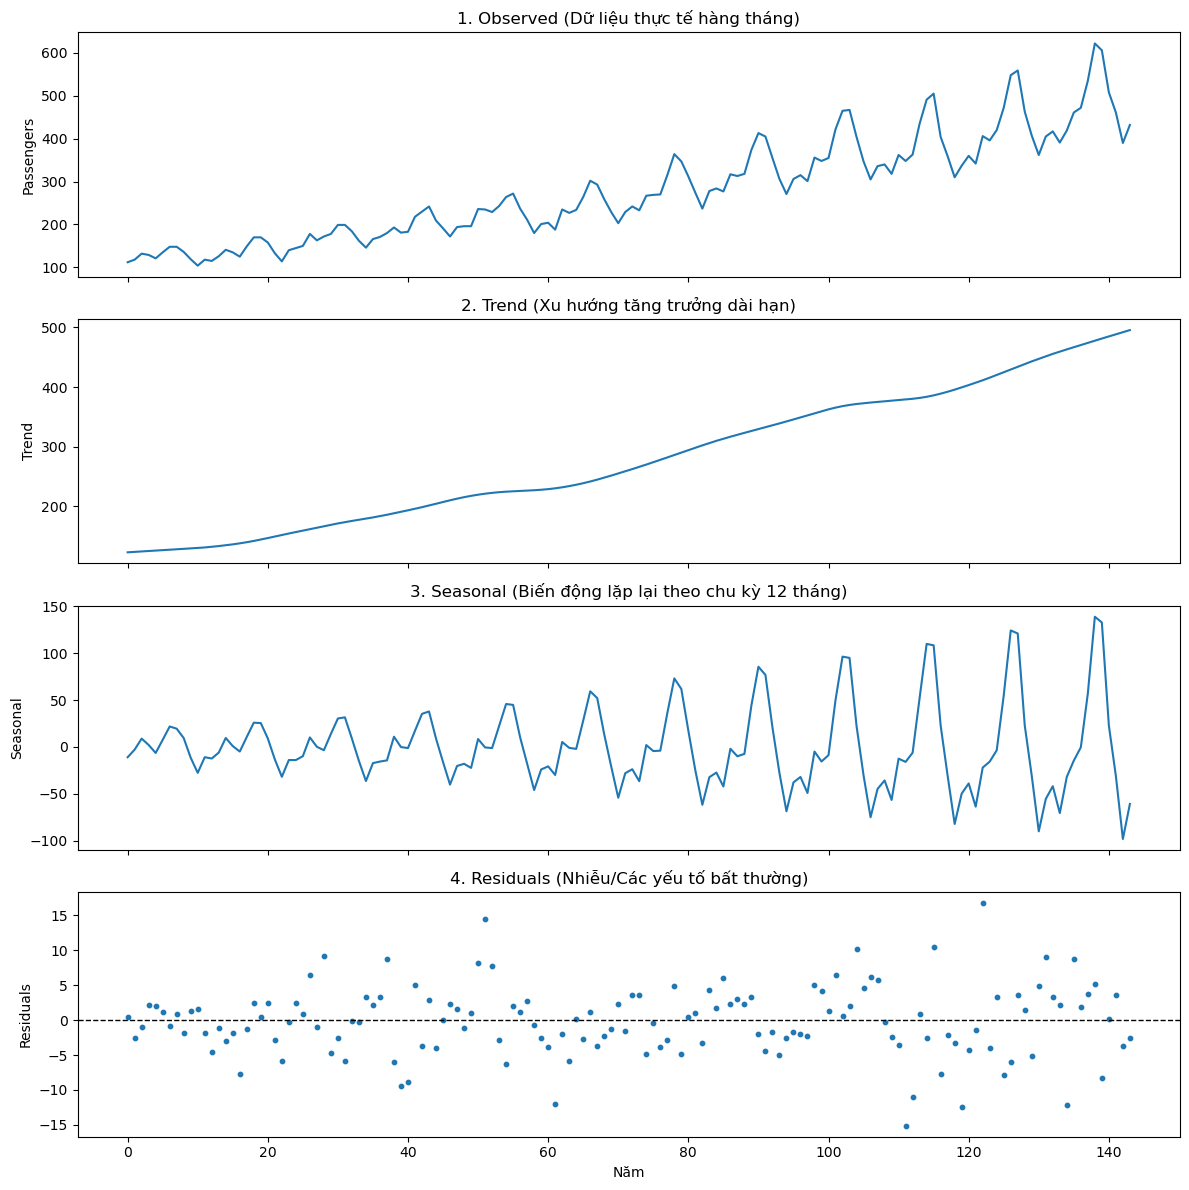

In [21]:
# from statsmodels.tsa.seasonal import STL (đã import ở trên cùng)

# Thực hiện STL
stl = STL(df["Passengers"], period=12)
res = stl.fit()

# Tạo khung hình với 4 biểu đồ con
fig, (ax1, ax2, ax3, ax4) = plt.subplots(4, 1, figsize=(12, 12), sharex=True)

# 1. Biểu đồ Dữ liệu gốc
ax1.plot(res.observed)
ax1.set_ylabel('Passengers')
ax1.set_title('1. Observed (Dữ liệu thực tế hàng tháng)')

# 2. Biểu đồ Xu hướng
ax2.plot(res.trend)
ax2.set_ylabel('Trend')
ax2.set_title('2. Trend (Xu hướng tăng trưởng dài hạn)')

# 3. Biểu đồ Mùa vụ
ax3.plot(res.seasonal)
ax3.set_ylabel('Seasonal')
ax3.set_title('3. Seasonal (Biến động lặp lại theo chu kỳ 12 tháng)')

# 4. Biểu đồ Phần dư
ax4.scatter(res.resid.index, res.resid, s=10)
ax4.axhline(0, color='black', linestyle='--', linewidth=1)
ax4.set_ylabel('Residuals')
ax4.set_title('4. Residuals (Nhiễu/Các yếu tố bất thường)')
ax4.set_xlabel('Năm')

plt.tight_layout()
plt.show()

## Câu 1, 2. Chuỗi dữ liệu được chọn
- Chuỗi Monthly Air Passengers
- Tần suất: hàng tháng
- Chu kỳ mùa vụ: 12 tháng
- Phương pháp: STL (Seasonal and Trend decomposition using Loess)

## Câu 3. Nhận xét từng thành phần
Observed – Dữ liệu gốc
- Chuỗi thể hiện:
- Xu hướng tăng rõ rệt theo thời gian
- Biến động theo mùa lặp lại hàng năm
- Biên độ dao động tăng dần theo thời gian → dấu hiệu mùa vụ dạng nhân
Trend – Xu hướng
- Thành phần trend:
    - Tăng liên tục và mạnh mẽ trong suốt giai đoạn quan sát
    - Tăng chậm ở giai đoạn đầu (1949–1953)
    - Tăng nhanh hơn về các năm cuối (1957–1960)
    - Không có giai đoạn suy giảm

=> Kết luận: Chuỗi có xu hướng tăng dài hạn rõ ràng.

Seasonal – Mùa vụ
- Thành phần seasonal:
    - Lặp lại ổn định theo chu kỳ 12 tháng
    - Đỉnh rơi vào giữa năm (mùa du lịch)
    - Đáy thường ở đầu hoặc cuối năm
    - Biên độ dao động tương đối lớn và ổn định về hình dạng

=> Kết luận: Mùa vụ mạnh và rõ ràng, đóng vai trò quan trọng trong chuỗi.

Residual – Phần dư
- Residual:
    - Dao động quanh 0
    - Không có xu hướng rõ rệt
    - Không xuất hiện chu kỳ lặp lại
    - Một vài điểm dao động lớn nhưng không có cấu trúc hệ thống

=> Kết luận: Residual gần giống white noise, cho thấy STL đã tách tốt trend và seasonal.

## Câu 4: Mô tả 

Xu hướng tăng hay giảm?
- Chuỗi có xu hướng tăng mạnh và liên tục theo thời gian.

Mùa vụ mạnh hay yếu?
- Mùa vụ mạnh, lặp lại rõ ràng hàng năm.
- Thành phần seasonal chiếm tỷ trọng đáng kể trong biến động tổng thể.

Residual có giống white noise không?
- Gần giống white noise:
- Dao động ngẫu nhiên quanh 0
- Không có xu hướng hay mùa vụ
Tuy nhiên vẫn tồn tại một số nhiễu nhỏ → dữ liệu thực tế

# Bài tập 4: Kiểm tra và xử lý chất lượng dữ liệu
1. Tạo dữ liệu thiếu (NaN) giả lập hoặc dùng dataset có missing.
2. Kiểm tra missing: isna().sum()
3. Xử lý missing bằng 2 cách: Forward-fill và Interpolation
4. Phát hiện outliers bằng: Rolling mean/variance; Z-score hoặc 
IQR
5. Vẽ trước và sau khi xử lý.

## Câu 1. Tạo dữ liệu thiếu (Missing Values)

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("data/airline-passengers.csv")

df["Passengers_missing"] = df["Passengers"].copy()

missing_idx = [20, 45, 80, 120]
df.loc[missing_idx, "Passengers_missing"] = np.nan


## Câu 2. Kiểm tra missing values

In [26]:
df.isna().sum()

Month                 0
Passengers            0
Passengers_missing    4
dtype: int64

Cột Month không có giá trị thiếu, cho thấy trục thời gian đầy đủ và liên tục.

Cột Passengers không có missing values, xác nhận dữ liệu gốc có chất lượng tốt.

Cột Passengers_missing có 4 giá trị bị thiếu, đúng với số lượng missing đã được tạo giả lập trước đó.

## Câu 3. Xử lý missing values

In [34]:
# Forward Fill
df["Passengers_ffill"] = df["Passengers_missing"].ffill()

# Interpolation
df["Passengers_interp"] = df["Passengers_missing"].interpolate(method="linear")

## Câu 4. Phát hiện Outliers

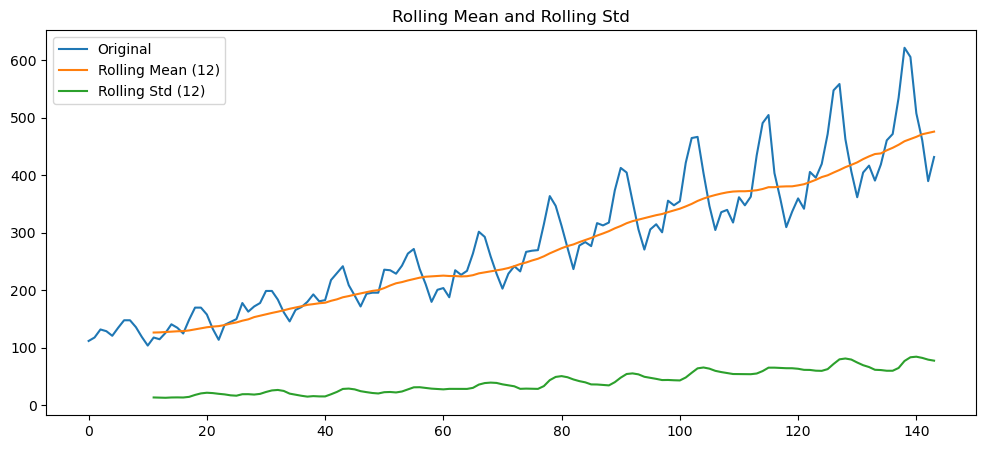

In [30]:
rolling_mean = df["Passengers"].rolling(window=12).mean()
rolling_std = df["Passengers"].rolling(window=12).std()

plt.figure(figsize=(12,5))
plt.plot(df["Passengers"], label="Original")
plt.plot(rolling_mean, label="Rolling Mean (12)")
plt.plot(rolling_std, label="Rolling Std (12)")
plt.legend()
plt.title("Rolling Mean and Rolling Std")
plt.show()


In [31]:
from scipy.stats import zscore

z_scores = np.abs(zscore(df["Passengers"]))
outliers_z = df[z_scores > 3]
outliers_z


,Month,Passengers,Passengers_missing,Passengers_ffill,Passengers_interp


=> DataFrame rỗng => Không tồn tại outlier mạnh theo tiêu chí Z-score

In [32]:
Q1 = df["Passengers"].quantile(0.25)
Q3 = df["Passengers"].quantile(0.75)
IQR = Q3 - Q1

outliers_iqr = df[
    (df["Passengers"] < Q1 - 1.5 * IQR) |
    (df["Passengers"] > Q3 + 1.5 * IQR)
]
outliers_iqr


,Month,Passengers,Passengers_missing,Passengers_ffill,Passengers_interp


=> DataFrame rỗng => Không tồn tại outlier theo tiêu chí IQR

## Câu 5. Vẽ dữ liệu trước và sau khi xử lý missing

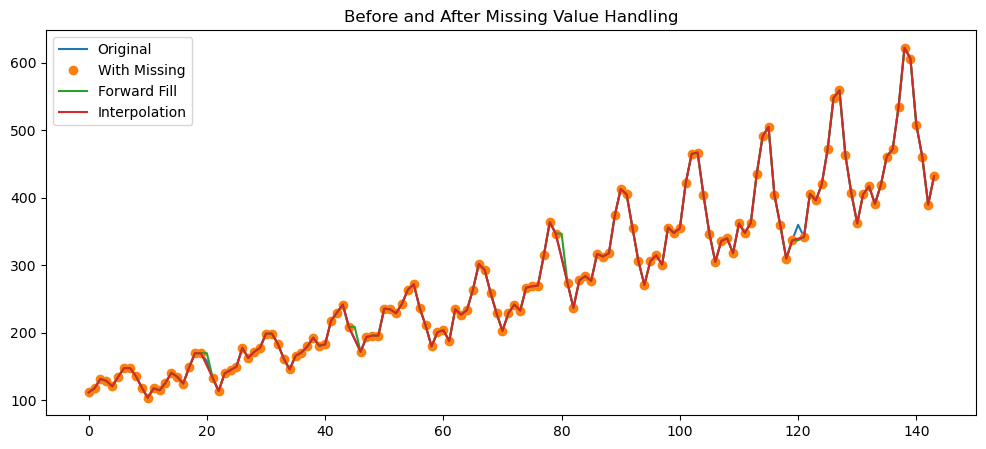

In [33]:
plt.figure(figsize=(12,5))
plt.plot(df["Passengers"], label="Original")
plt.plot(df["Passengers_missing"], 'o', label="With Missing")
plt.plot(df["Passengers_ffill"], label="Forward Fill")
plt.plot(df["Passengers_interp"], label="Interpolation")
plt.legend()
plt.title("Before and After Missing Value Handling")
plt.show()


Dữ liệu gốc (Original – đường xanh):
- Chuỗi AirPassengers thể hiện xu hướng tăng rõ rệt theo thời gian và mùa vụ mạnh theo chu kỳ 12 tháng (đỉnh – đáy lặp lại đều). Đây là đặc trưng điển hình của dữ liệu hành khách hàng không.

Dữ liệu có missing (With Missing – chấm cam):
- Các điểm bị thiếu tạo ra khoảng trống/đứt quãng cục bộ, làm gián đoạn chuỗi và gây khó khăn cho phân tích ACF/PACF, decomposition hay mô hình hóa nếu không xử lý trước.

Forward Fill (đường xanh lá):

- Điền giá trị thiếu bằng giá trị gần nhất trước đó.

- Ưu điểm: đơn giản, nhanh, giữ được mức gần nhất.

- Nhược điểm: tạo đoạn “phẳng” giả tạo, có thể làm méo mùa vụ nếu missing rơi vào pha tăng/giảm.

Interpolation (đường đỏ):

- Nội suy mượt giữa các điểm trước–sau.

- Bám sát xu hướng và mùa vụ tốt hơn forward fill.

- Phù hợp hơn với chuỗi liên tục theo thời gian như AirPassengers.

So sánh tổng thể:

- Cả hai cách đều giúp khôi phục tính liên tục của chuỗi.

- Interpolation cho kết quả tự nhiên và hợp lý hơn trong bối cảnh dữ liệu có xu hướng + mùa vụ rõ ràng.

- Forward fill chỉ nên dùng khi missing rất ít và không nằm ở đoạn biến động mạnh.

=> Kết luận:
- Với chuỗi AirPassengers, Interpolation là phương pháp xử lý missing phù hợp hơn, giúp bảo toàn cấu trúc xu hướng và mùa vụ, từ đó cho kết quả phân tích và mô hình hóa đáng tin cậy hơn.

# Bài tập 5: Trực quan hóa dữ liệu chuỗi thời gian
1. Vẽ line chart toàn bộ chuỗi.
2. Vẽ rolling mean (window=12) và rolling std.
3. Vẽ seasonal plot theo tháng (đối với dữ liệu theo tháng).
4. Vẽ heatmap seasonality (month × year).
5. Kết luận: Xu hướng chung, các mùa vụ nổi bật, bất thường (nếu 
có)

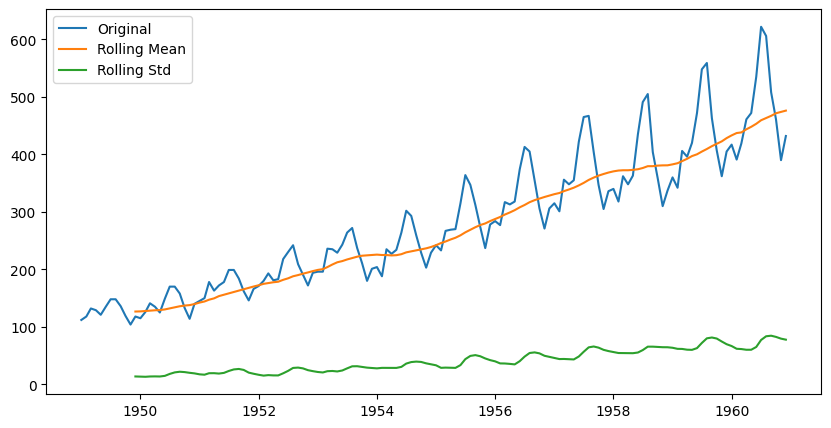

In [ ]:
# Rolling mean & std
rolling_mean = df["Passengers"].rolling(12).mean()
rolling_std = df["Passengers"].rolling(12).std()

plt.figure()
plt.plot(df["Passengers"], label="Original")
plt.plot(rolling_mean, label="Rolling Mean")
plt.plot(rolling_std, label="Rolling Std")
plt.legend()
plt.show()

Giải thích:

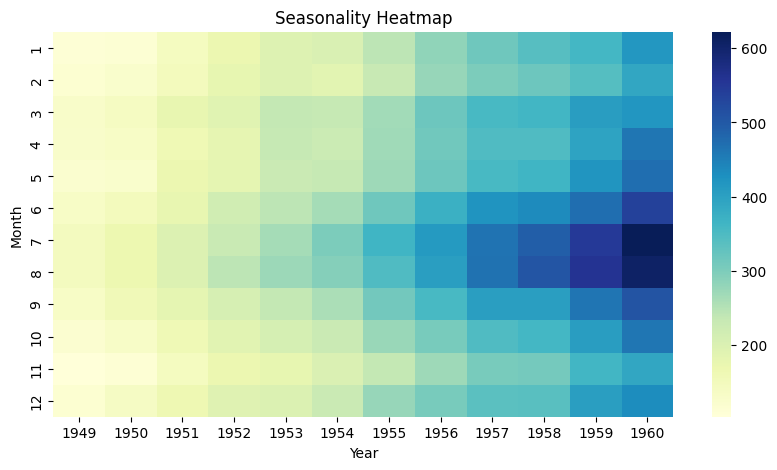

In [ ]:
# Heatmap seasonality
# import seaborn as sns (đã import ở trên)

df_season = df.copy()
df_season["Year"] = df_season.index.year
df_season["Month"] = df_season.index.month

pivot = df_season.pivot(index="Month", columns="Year", values="Passengers")

plt.figure()
sns.heatmap(pivot, cmap="YlGnBu")
plt.title("Seasonality Heatmap")
plt.show()

## Câu 1. Vẽ line chart toàn bộ chuỗi

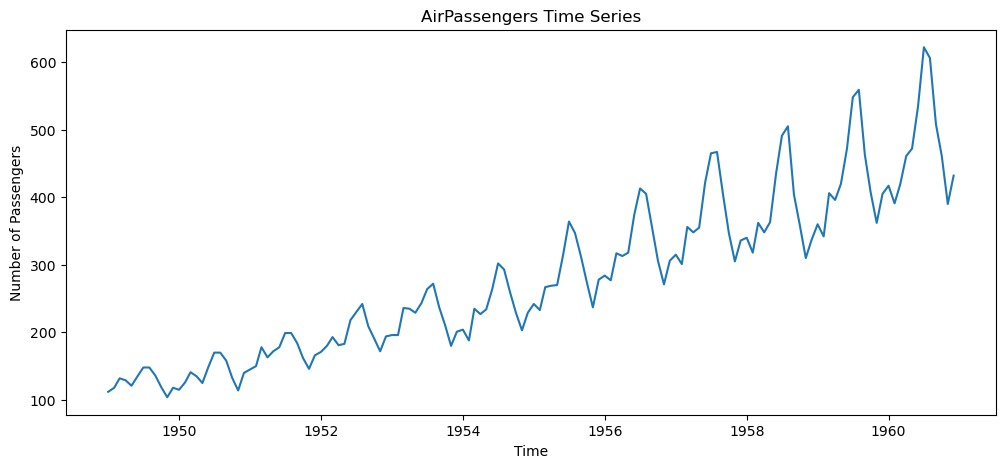

In [35]:
import pandas as pd
import matplotlib.pyplot as plt

# Đọc dữ liệu
df = pd.read_csv("data/airline-passengers.csv")
df["Month"] = pd.to_datetime(df["Month"])
df.set_index("Month", inplace=True)

# Line chart
plt.figure(figsize=(12,5))
plt.plot(df["Passengers"])
plt.title("AirPassengers Time Series")
plt.xlabel("Time")
plt.ylabel("Number of Passengers")
plt.show()


Nhận xét
- Chuỗi có xu hướng tăng rất rõ rệt theo thời gian.
- Biên độ dao động ngày càng lớn → dấu hiệu không dừng (non-stationary).
- Mùa vụ lặp lại đều qua các năm.

## Câu 2. Vẽ Rolling Mean và Rolling Std (window = 12)

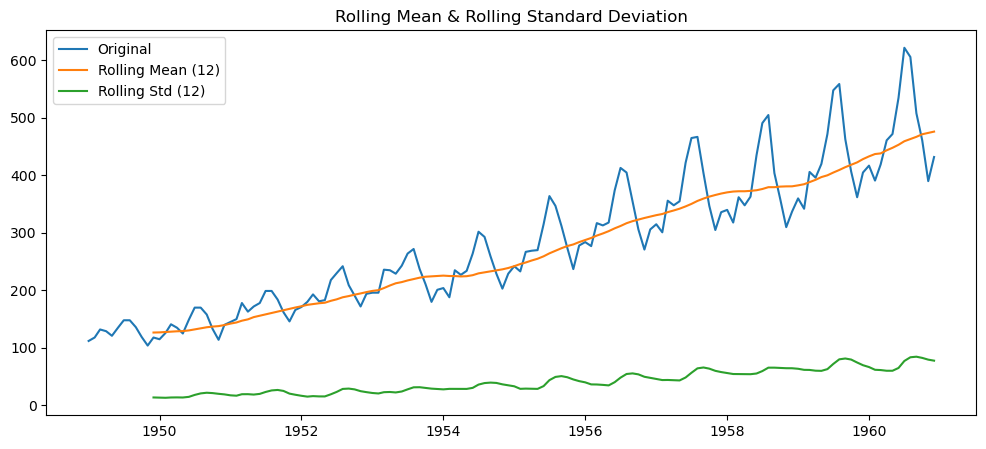

In [36]:
# Rolling statistics
rolling_mean = df["Passengers"].rolling(window=12).mean()
rolling_std = df["Passengers"].rolling(window=12).std()

plt.figure(figsize=(12,5))
plt.plot(df["Passengers"], label="Original")
plt.plot(rolling_mean, label="Rolling Mean (12)")
plt.plot(rolling_std, label="Rolling Std (12)")
plt.legend()
plt.title("Rolling Mean & Rolling Standard Deviation")
plt.show()


Nhận xét
- Rolling mean tăng dần → xác nhận xu hướng tăng dài hạn.
- Rolling std cũng tăng → mức độ biến động ngày càng lớn.
- Chuỗi không thỏa mãn giả định stationarity.

## Câu 3. Vẽ Seasonal Plot theo tháng

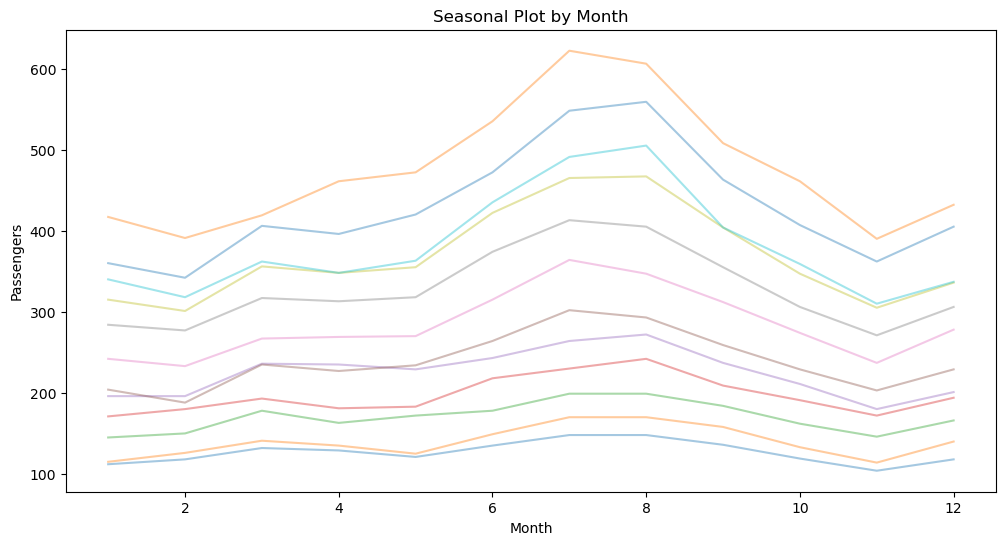

In [37]:
# Thêm cột tháng và năm
df_seasonal = df.copy()
df_seasonal["Month_num"] = df_seasonal.index.month
df_seasonal["Year"] = df_seasonal.index.year

plt.figure(figsize=(12,6))
for year in df_seasonal["Year"].unique():
    data_year = df_seasonal[df_seasonal["Year"] == year]
    plt.plot(data_year["Month_num"], data_year["Passengers"], alpha=0.4)

plt.title("Seasonal Plot by Month")
plt.xlabel("Month")
plt.ylabel("Passengers")
plt.show()


Nhận xét
- Mỗi năm có hình dạng mùa vụ rất giống nhau.
- Đỉnh thường rơi vào giữa năm (tháng 7–8).
- Đáy vào đầu và cuối năm → mùa thấp điểm.

## Câu 4. Vẽ Heatmap Seasonality (Month × Year)

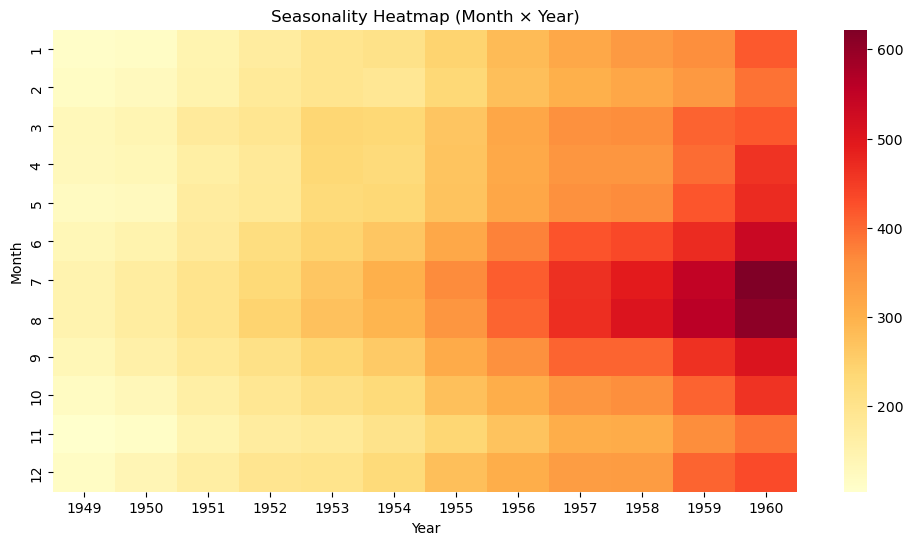

In [38]:
import seaborn as sns

# Pivot table cho heatmap
heatmap_data = df_seasonal.pivot_table(
    values="Passengers",
    index="Month_num",
    columns="Year"
)

plt.figure(figsize=(12,6))
sns.heatmap(heatmap_data, cmap="YlOrRd")
plt.title("Seasonality Heatmap (Month × Year)")
plt.xlabel("Year")
plt.ylabel("Month")
plt.show()


Nhận xét

- Màu sắc đậm dần theo năm → lượng hành khách tăng mạnh qua thời gian.
- Các tháng mùa hè luôn có giá trị cao hơn rõ rệt.
- Không thấy năm nào có giá trị bất thường quá lớn hoặc quá nhỏ so với xu hướng chung

## Câu 5. Kết luận chung

Xu hướng:
- Chuỗi tăng mạnh và liên tục → xu hướng dài hạn rõ ràng.

Mùa vụ:
- Mùa vụ rất mạnh, lặp lại ổn định theo chu kỳ 12 tháng.

Bất thường:
- Không có outlier nghiêm trọng; biến động tăng dần là tự nhiên theo tăng trưởng.